# Selección de datos

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [28]:
df = pd.read_csv("laClosa.csv")
df.head()

,instante,HS10,HS20,HS30,HS40,HS50,HS60,TS30,TA,HA,litros_arbol,litros_incremento,riego
0,2020-03-01 00:00:00,0.6943,0.7429,0.7664,0.774,0.7801,0.7979,14.68,20.180,0.4929,62.181818,NaN,NaN
1,2020-03-01 00:09:00,0.6940,0.7429,0.7662,0.774,0.7799,0.7979,14.68,20.100,0.4977,62.181818,0.0,0.0
2,2020-03-01 00:18:00,0.6932,0.7429,0.7662,0.774,0.7800,0.7981,14.68,19.995,0.5042,62.181818,0.0,0.0
3,2020-03-01 00:27:00,0.6930,0.7426,0.7662,0.774,0.7799,0.7979,14.68,19.990,0.5121,62.181818,0.0,0.0
4,2020-03-01 00:36:00,0.6935,0.7429,0.7662,0.774,0.7799,0.7979,14.68,19.720,0.5260,62.181818,0.0,0.0


## DF Horario

In [4]:
df = pd.read_csv("csv/laClosa.csv")
dft = pd.read_csv("csv/meteoLC.csv")

In [49]:
dft.head()

,fecha,hora,tmedia,hmedia,radiacion,viento,direccion,direccion_num,precipitacion,sestado
0,2020-03-01,00:30,17.97,55.42,0.0,8.54,O,267.9,0.0,Sin incidencias
1,2020-03-01,01:00,17.49,57.25,0.0,7.56,O,264.2,0.0,Sin incidencias
2,2020-03-01,01:30,17.22,57.64,0.0,6.50,O,278.8,0.0,Sin incidencias
3,2020-03-01,02:00,16.70,57.12,0.0,6.03,O,272.0,0.0,Sin incidencias
4,2020-03-01,02:30,16.88,55.54,0.0,8.02,O,281.3,0.0,Sin incidencias


In [5]:
df['instante'] = pd.to_datetime(df['instante'])
df = df.set_index('instante')

cols_stats = [c for c in df.columns if c != 'litros_incremento' and c != 'litros_arbol' and c != 'riego']
df_hourly = df.resample('h').agg({
    **{col: ['mean', 'median', 'min', 'max', 'std', 'count'] for col in cols_stats},
    'litros_incremento': 'sum'
})

df_hourly.columns = [
    f"{col}_{stat}" if stat != '' else col
    for col, stat in df_hourly.columns
]

df_hourly = df_hourly.reset_index()

In [6]:
df_hourly.head()

,instante,HS10_mean,HS10_median,HS10_min,HS10_max,HS10_std,HS10_count,HS20_mean,HS20_median,HS20_min,...,TA_max,TA_std,TA_count,HA_mean,HA_median,HA_min,HA_max,HA_std,HA_count,litros_incremento_sum
0,2020-03-01 00:00:00,0.693457,0.693200,0.6930,0.6943,0.000509,7,0.742771,0.74290,0.74260,...,20.180,0.180413,7,0.512743,0.512100,0.49290,0.5283,0.014967,7,0.0
1,2020-03-01 01:00:00,0.692457,0.692500,0.6919,0.6930,0.000378,7,0.742486,0.74240,0.74240,...,19.780,0.323080,7,0.546371,0.547800,0.52770,0.5595,0.011751,7,0.0
2,2020-03-01 02:00:00,0.691325,0.691325,0.6910,0.6916,0.000252,6,0.742442,0.74245,0.74235,...,18.960,0.102103,4,0.541420,0.537600,0.53240,0.5580,0.010455,5,0.0
3,2020-03-01 03:00:00,0.690629,0.690600,0.6903,0.6909,0.000214,7,0.742200,0.74220,0.74220,...,18.615,0.122226,7,0.538407,0.536900,0.53405,0.5472,0.004560,7,0.0
4,2020-03-01 04:00:00,0.689857,0.689800,0.6892,0.6903,0.000354,7,0.741843,0.74190,0.74170,...,18.530,0.091869,6,0.541125,0.540375,0.53680,0.5463,0.003880,6,0.0


In [ ]:
import pandas as pd

cols_hs = [c for c in df_hourly.columns 
           if c.startswith(('HS10', 'HS20', 'HS30', 
                            'HS40', 'HS50', 'HS60'))]

df_hs = df_hourly[cols_hs]

df_filtered = df_hs.loc[
    (df_hs.index.year >= 2020) & (df_hs.index.year <= 2023) &
    (df_hs.index.month >= 3) & (df_hs.index.month <= 11)
]

null_mask = df_filtered.isna()
null_count = null_mask.sum(axis=1)
null_columns = null_mask.apply(lambda row: list(row.index[row]), axis=1)

df_nulls = pd.DataFrame({
    'num_nulos': null_count,
    'variables_nulas': null_columns
})

df_nulls = df_nulls[df_nulls['num_nulos'] > 0]

print(df_nulls)

total_horas_con_nulos = df_nulls.shape[0]

print("\nTotal de horas con al menos un NaN (Marzo-Nov 2020-2023):", total_horas_con_nulos)

                     num_nulos  \
instante                         
2020-03-29 02:00:00         15   
2020-04-12 07:00:00          1   
2020-05-07 13:00:00         30   
2020-05-07 14:00:00         30   
2020-05-07 15:00:00         30   
...                        ...   
2023-11-12 21:00:00         30   
2023-11-12 22:00:00         30   
2023-11-12 23:00:00         30   
2023-11-15 01:00:00          1   
2023-11-27 19:00:00          5   

                                                       variables_nulas  
instante                                                                
2020-03-29 02:00:00  [HS20_mean, HS20_median, HS20_min, HS20_max, H...  
2020-04-12 07:00:00                                         [HS10_std]  
2020-05-07 13:00:00  [HS10_mean, HS10_median, HS10_min, HS10_max, H...  
2020-05-07 14:00:00  [HS10_mean, HS10_median, HS10_min, HS10_max, H...  
2020-05-07 15:00:00  [HS10_mean, HS10_median, HS10_min, HS10_max, H...  
...                                           

1495 horas son 60 dias aprox 2 meses q elimino

In [46]:
df_nulls.to_csv('horas_con_nulos_HS10_60.csv', index=True)


In [ ]:
import pandas as pd
from datetime import timedelta

if 'instante' not in df_hourly.columns:
    df_hourly = df_hourly.reset_index()
df_hourly['instante'] = pd.to_datetime(df_hourly['instante'])

cols_hs_litros = [c for c in df_hourly.columns 
                  if c.startswith(('HS10','HS20','HS30','HS40','HS50','HS60'))] + ['litros_incremento_sum']
df_hourly_sel = df_hourly[['instante'] + cols_hs_litros]

def fix_24h(row):
    if row['hora'] == "24:00":
        return pd.to_datetime(row['fecha']) + pd.Timedelta(days=1)
    else:
        return pd.to_datetime(str(row['fecha']) + ' ' + str(row['hora']))

dft['instante'] = dft.apply(fix_24h, axis=1)

df_combined = pd.merge(df_hourly, dft.drop(columns=['fecha','hora']),
                       on='instante', how='left')

df_combined = df_combined.sort_values('instante').reset_index(drop=True)

cols_to_copy = ['tmedia','hmedia','viento','direccion','direccion_num','precipitacion','sestado']

anos = [2020, 2021, 2022, 2023]

for ano in anos:
    fila_dft = dft[(dft['fecha'] == f"{ano}-03-01") & (dft['hora'] == "00:30")]
    
    instante_combined = pd.Timestamp(f"{ano}-03-01 00:00:00")
    
    if not fila_dft.empty:
        for col in cols_to_copy:
            if col in df_combined.columns and col in fila_dft.columns:
                df_combined.loc[df_combined['instante'] == instante_combined, col] = fila_dft.iloc[0][col]
    
    if 'radiacion' in df_combined.columns:
        df_combined.loc[df_combined['instante'] == instante_combined, 'radiacion'] = 0.0

print(df_combined.head())

             instante  HS10_mean  HS10_median  HS10_min  HS10_max  HS10_std  \
0 2020-03-01 00:00:00   0.693457     0.693200    0.6930    0.6943  0.000509   
1 2020-03-01 01:00:00   0.692457     0.692500    0.6919    0.6930  0.000378   
2 2020-03-01 02:00:00   0.691325     0.691325    0.6910    0.6916  0.000252   
3 2020-03-01 03:00:00   0.690629     0.690600    0.6903    0.6909  0.000214   
4 2020-03-01 04:00:00   0.689857     0.689800    0.6892    0.6903  0.000354   

   HS10_count  HS20_mean  HS20_median  HS20_min  ...  HA_count  \
0           7   0.742771      0.74290   0.74260  ...         7   
1           7   0.742486      0.74240   0.74240  ...         7   
2           6   0.742442      0.74245   0.74235  ...         5   
3           7   0.742200      0.74220   0.74220  ...         7   
4           7   0.741843      0.74190   0.74170  ...         6   

   litros_incremento_sum  tmedia  hmedia  radiacion  viento  direccion  \
0                    0.0   17.97   55.42        0.0   

In [ ]:
import pandas as pd

df_filtered = df_combined.loc[
    (df_combined['instante'].dt.year >= 2020) & (df_combined['instante'].dt.year <= 2023) &
    (df_combined['instante'].dt.month >= 3) & (df_combined['instante'].dt.month <= 11)
]

null_mask = df_filtered.isna()
null_count = null_mask.sum(axis=1)
null_columns = null_mask.apply(lambda row: list(row.index[row]), axis=1)

df_nulls = pd.DataFrame({
    'num_nulos': null_count,
    'variables_nulas': null_columns
}, index=df_filtered.index)

df_nulls = df_nulls[df_nulls['num_nulos'] > 0]

print(df_nulls)

       num_nulos                                    variables_nulas
170           10  [TA_mean, TA_median, TA_min, TA_max, TA_std, H...
674           15  [HS20_mean, HS20_median, HS20_min, HS20_max, H...
1015           3                       [HS10_std, TS30_std, TA_std]
1201          10  [TA_mean, TA_median, TA_min, TA_max, TA_std, H...
1202          10  [TA_mean, TA_median, TA_min, TA_max, TA_std, H...
...          ...                                                ...
32838          2                                   [TA_std, HA_std]
32850          3                         [TS30_std, TA_std, HA_std]
32851          3                         [TS30_std, TA_std, HA_std]
32852          2                                   [TA_std, HA_std]
32853          2                                   [TA_std, HA_std]

[3005 rows x 2 columns]


In [ ]:
import pandas as pd

cols_dft = ['tmedia','hmedia','viento','direccion','direccion_num','precipitacion','sestado']

df_filtered = df_combined.loc[
    (df_combined['instante'].dt.year >= 2020) & (df_combined['instante'].dt.year <= 2023) &
    (df_combined['instante'].dt.month >= 3) & (df_combined['instante'].dt.month <= 11)
]

null_mask = df_filtered[cols_dft].isna()
null_count = null_mask.sum(axis=1)
null_columns = null_mask.apply(lambda row: list(row.index[row]), axis=1)

df_nulls_dft = pd.DataFrame({
    'fecha': df_filtered['instante'].dt.date,
    'hora': df_filtered['instante'].dt.time,
    'num_nulos': null_count,
    'variables_nulas': null_columns
})

df_nulls_dft = df_nulls_dft[df_nulls_dft['num_nulos'] > 0]

print(df_nulls_dft)
total_horas_con_nulos = df_nulls_dft.shape[0]
print("\nTotal de horas con al menos un NaN en columnas DFT (Marzo-Nov 2020-2023):", total_horas_con_nulos)

            fecha      hora  num_nulos  \
14045  2021-10-07  05:00:00          7   
14046  2021-10-07  06:00:00          7   
14047  2021-10-07  07:00:00          7   
14048  2021-10-07  08:00:00          7   
14049  2021-10-07  09:00:00          7   
14050  2021-10-07  10:00:00          7   
14051  2021-10-07  11:00:00          7   
14052  2021-10-07  12:00:00          7   
14053  2021-10-07  13:00:00          7   
14054  2021-10-07  14:00:00          7   
14055  2021-10-07  15:00:00          7   
14056  2021-10-07  16:00:00          7   
14057  2021-10-07  17:00:00          7   
14058  2021-10-07  18:00:00          7   
14059  2021-10-07  19:00:00          7   
14060  2021-10-07  20:00:00          7   
14061  2021-10-07  21:00:00          7   
14239  2021-10-15  07:00:00          7   
14240  2021-10-15  08:00:00          7   
14241  2021-10-15  09:00:00          7   
14242  2021-10-15  10:00:00          7   
14243  2021-10-15  11:00:00          7   
14244  2021-10-15  12:00:00       

In [10]:
df_combined.to_csv("LC_horario.csv")

# DF Drenaje

In [4]:
df = pd.read_csv("csv/LC_horario.csv")
df = df.iloc[:, 1:]


In [5]:
df["instante"] = pd.to_datetime(df["instante"])
df = df.sort_values("instante").copy()
df["year"] = df["instante"].dt.year
df["month"] = df["instante"].dt.month
df = df[df["month"].between(3, 11)].copy()
df.shape

(26400, 66)

In [8]:
for col in ['HS10_mean', 'HS20_mean', 'HS30_mean', 'HS40_mean', 'HS50_mean', 'HS60_mean', 'TS30_mean', 'tmedia','hmedia']:
    print(f"{col}: {df[col].isna().sum()} nulos de {len(df)} filas")

HS10_mean: 925 nulos de 26400 filas
HS20_mean: 855 nulos de 26400 filas
HS30_mean: 944 nulos de 26400 filas
HS40_mean: 859 nulos de 26400 filas
HS50_mean: 937 nulos de 26400 filas
HS60_mean: 951 nulos de 26400 filas
TS30_mean: 1138 nulos de 26400 filas
tmedia: 32 nulos de 26400 filas
hmedia: 32 nulos de 26400 filas


In [ ]:
def detectar_tramos(grupo, columna, umbral=0.002, ventana_ruido=5):
    grupo = grupo.sort_values("instante").copy()
    grupo = grupo[grupo[columna].notna()].copy()
    grupo = grupo.reset_index(drop=True)

    def sin_ruido(i):
        row = grupo.iloc[i]
        return row.get("var_precipitacion", 0) == 0 and row.get("litros_incremento_sum", 0) == 0

    def es_ruido(i):
        if i == 0 or i + 1 >= len(grupo):
            return False
        val_a = grupo.iloc[i - 1][columna]
        val_b = grupo.iloc[i][columna]

        # La subida debe ser positiva y menor que umbral
        if not (0 < (val_b - val_a) < umbral):
            return False

        # Buscar en las siguientes ventana_ruido posiciones un valor estrictamente menor que b
        for j in range(i + 1, min(i + 1 + ventana_ruido, len(grupo))):
            val_j = grupo.iloc[j][columna]
            if val_j < val_b:  # estrictamente menor que b
                return True

        return False

    tramo_id = 0
    tramo_list = [None] * len(grupo)

    prev_val = None
    prev_sin_ruido = None
    i = 0

    while i < len(grupo):
        val = grupo.iloc[i][columna]
        act_sin_ruido = sin_ruido(i)

        if prev_val is None:
            tramo_list[i] = None
        else:
            diff = val - prev_val
            es_descenso = diff <= 0  # estrictamente descendente

            # Corte inmediato si hay lluvia o litros en instante actual O anterior
            if not act_sin_ruido or not prev_sin_ruido:
                tramo_list[i] = None

            elif es_descenso:
                # Descenso normal, ambos instantes limpios
                if tramo_list[i - 1] is None:
                    tramo_id += 1
                    tramo_list[i - 1] = tramo_id
                tramo_list[i] = tramo_id

            elif tramo_list[i - 1] is not None and es_ruido(i):
                # Subida mínima (< umbral) y dentro de ventana hay uno estrictamente menor que b
                tramo_list[i] = tramo_list[i - 1]

            else:
                tramo_list[i] = None

        prev_val = val
        prev_sin_ruido = act_sin_ruido
        i += 1

    grupo["tramo_id"] = tramo_list
    grupo_tramos = grupo.dropna(subset=["tramo_id"]).copy()
    grupo_tramos["tramo_id"] = grupo_tramos["tramo_id"].astype(int)

    duraciones = grupo_tramos.groupby("tramo_id").size()
    grupo_tramos["duracion_tramo"] = grupo_tramos["tramo_id"].map(duraciones)

    tramo_hours = grupo_tramos.groupby("tramo_id")["instante"].agg(
        lambda x: (x.max() - x.min()).total_seconds() / 3600 + 1
    )
    grupo_tramos["duracion_horas"] = grupo_tramos["tramo_id"].map(tramo_hours)

    return grupo_tramos

## HS10

In [76]:
df_desc1 = (
    df.groupby("year", group_keys=False)
      .apply(detectar_tramos, columna="HS10_mean")
)

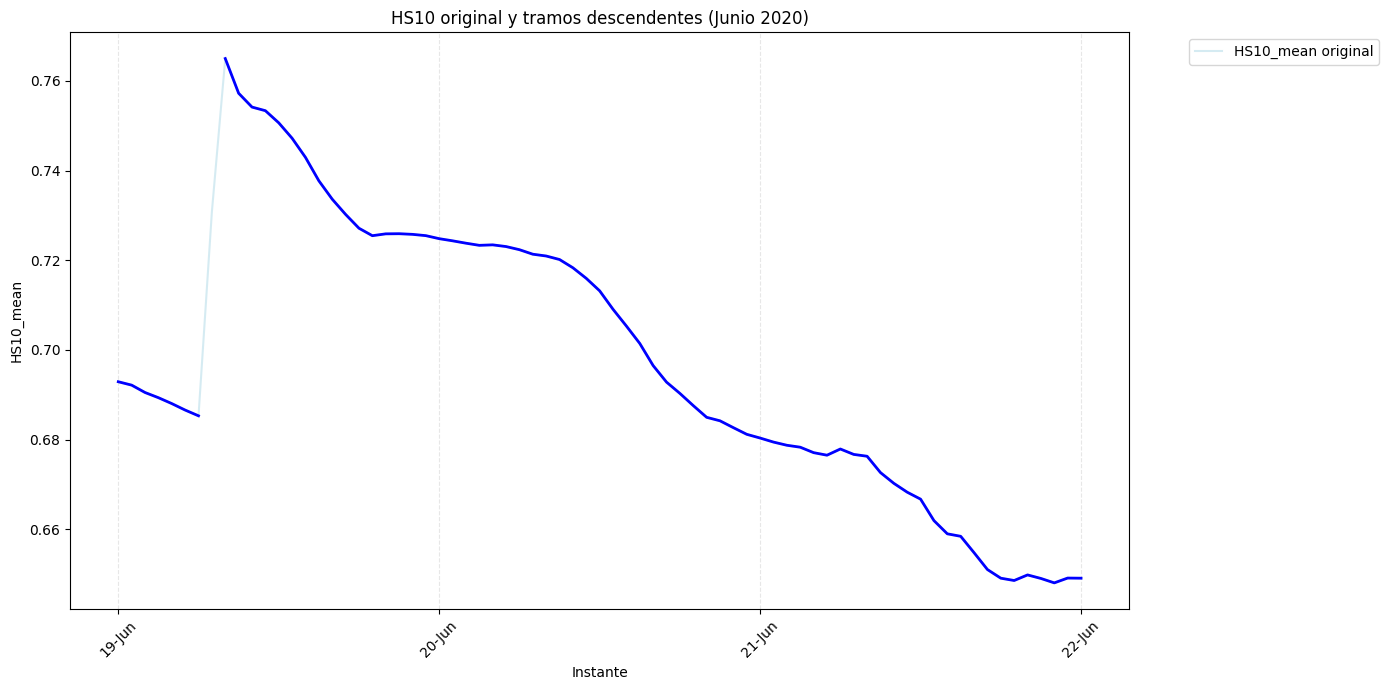

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

start_date = "2020-06-19"
end_date = "2020-06-22"

mask_df = (df["instante"] >= start_date) & (df["instante"] <= end_date)
mask_desc = (df_desc1["instante"] >= start_date) & (df_desc1["instante"] <= end_date)

df_plot = df.loc[mask_df].sort_values("instante").set_index("instante")
df_desc_plot = df_desc1.loc[mask_desc].sort_values("instante").set_index("instante")

full_range = pd.date_range(start=start_date, end=end_date, freq="h")
df_plot = df_plot.reindex(full_range)
df_desc_plot = df_desc_plot.reindex(full_range)

fig, ax = plt.subplots(figsize=(14,7))

ax.plot(df_plot.index, df_plot['HS10_mean'], label="HS10_mean original",
        alpha=0.5, color="lightblue")

if "tramo_id" in df_desc_plot.columns:
    for tramo_id in df_desc_plot['tramo_id'].dropna().unique():
        tramo = df_desc_plot[df_desc_plot['tramo_id'] == tramo_id]
        ax.plot(tramo.index, tramo['HS10_mean'], color="blue", linewidth=2)

ax.set_xlabel("Instante")
ax.set_ylabel("HS10_mean")

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.xaxis.set_major_locator(mdates.DayLocator()) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax.grid(True, axis='x', linestyle='--', alpha=0.3)

plt.title("HS10 original y tramos descendentes (Junio 2020)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

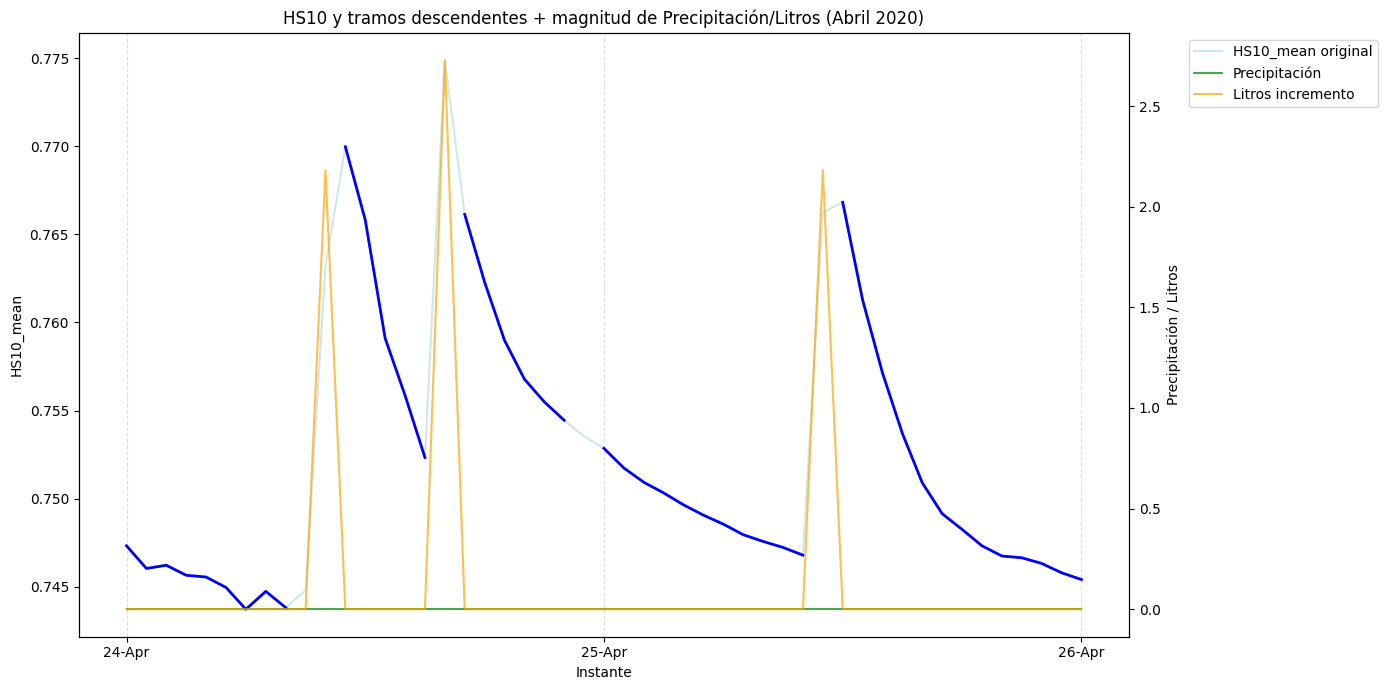

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

start_date = "2020-04-24"
end_date = "2020-04-26"

mask_df = (df["instante"] >= start_date) & (df["instante"] <= end_date)
mask_desc = (df_desc1["instante"] >= start_date) & (df_desc1["instante"] <= end_date)

df_plot = df.loc[mask_df].sort_values("instante").set_index("instante")
df_desc_plot = df_desc1.loc[mask_desc].sort_values("instante").set_index("instante")

full_range = pd.date_range(start=start_date, end=end_date, freq="h")
df_plot = df_plot.reindex(full_range)
df_desc_plot = df_desc_plot.reindex(full_range)

fig, ax1 = plt.subplots(figsize=(14,7))

ax1.plot(df_plot.index, df_plot['HS10_mean'],
         color="lightblue", alpha=0.6,
         label="HS10_mean original")

if "tramo_id" in df_desc_plot.columns:
    for tramo_id in df_desc_plot['tramo_id'].dropna().unique():
        tramo = df_desc_plot[df_desc_plot['tramo_id'] == tramo_id]
        ax1.plot(tramo.index, tramo['HS10_mean'], color="blue", linewidth=2)

ax1.set_xlabel("Instante")
ax1.set_ylabel("HS10_mean")

ax2 = ax1.twinx()

ax2.plot(df_plot.index, df_plot['precipitacion'], color="green",
         label="Precipitación", alpha=0.7)

ax2.plot(df_plot.index, df_plot['litros_incremento_sum'], color="orange",
         label="Litros incremento", alpha=0.7)

ax2.set_ylabel("Precipitación / Litros")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           bbox_to_anchor=(1.05, 1), loc='upper left')

ax1.xaxis.set_major_locator(mdates.DayLocator())  # un tick por día
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax1.grid(True, axis='x', linestyle='--', alpha=0.4)

plt.title("HS10 y tramos descendentes + magnitud de Precipitación/Litros (Abril 2020)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## HS20

In [77]:
df_desc2 = (
    df.groupby("year", group_keys=False)
      .apply(detectar_tramos, columna="HS20_mean")
)

## HS30

In [106]:
df_desc3 = (
    df.groupby("year", group_keys=False)
      .apply(detectar_tramos, columna="HS30_mean")
)

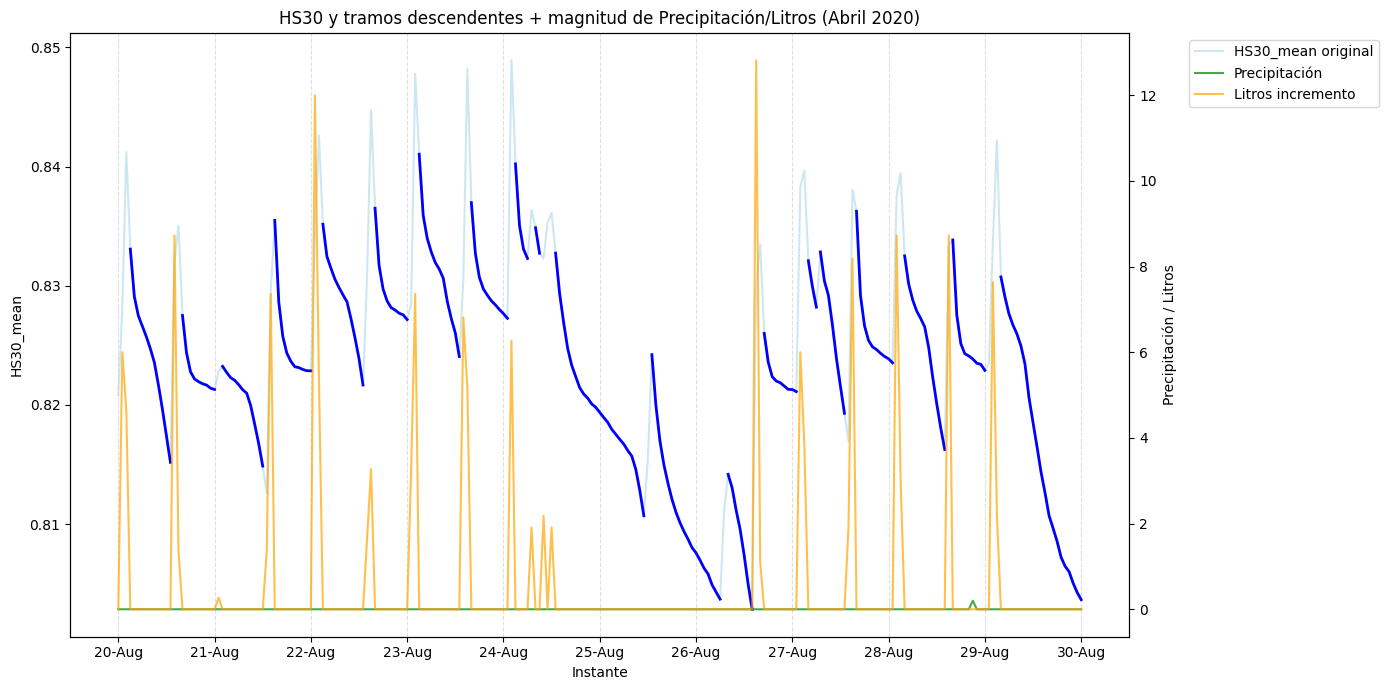

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

start_date = "2020-08-20"
end_date = "2020-08-30"

mask_df = (df["instante"] >= start_date) & (df["instante"] <= end_date)
mask_desc = (df_desc3["instante"] >= start_date) & (df_desc3["instante"] <= end_date)

df_plot = df.loc[mask_df].sort_values("instante").set_index("instante")
df_desc_plot = df_desc3.loc[mask_desc].sort_values("instante").set_index("instante")

full_range = pd.date_range(start=start_date, end=end_date, freq="h")
df_plot = df_plot.reindex(full_range)
df_desc_plot = df_desc_plot.reindex(full_range)

fig, ax1 = plt.subplots(figsize=(14,7))

ax1.plot(df_plot.index, df_plot['HS30_mean'],
         color="lightblue", alpha=0.6,
         label="HS30_mean original")

if "tramo_id" in df_desc_plot.columns:
    for tramo_id in df_desc_plot['tramo_id'].dropna().unique():
        tramo = df_desc_plot[df_desc_plot['tramo_id'] == tramo_id]
        ax1.plot(tramo.index, tramo['HS30_mean'], color="blue", linewidth=2)

ax1.set_xlabel("Instante")
ax1.set_ylabel("HS30_mean")

ax2 = ax1.twinx()

ax2.plot(df_plot.index, df_plot['precipitacion'], color="green",
         label="Precipitación", alpha=0.7)

ax2.plot(df_plot.index, df_plot['litros_incremento_sum'], color="orange",
         label="Litros incremento", alpha=0.7)

ax2.set_ylabel("Precipitación / Litros")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           bbox_to_anchor=(1.05, 1), loc='upper left')

ax1.xaxis.set_major_locator(mdates.DayLocator())  # un tick por día
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax1.grid(True, axis='x', linestyle='--', alpha=0.4)

plt.title("HS30 y tramos descendentes + magnitud de Precipitación/Litros (Abril 2020)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

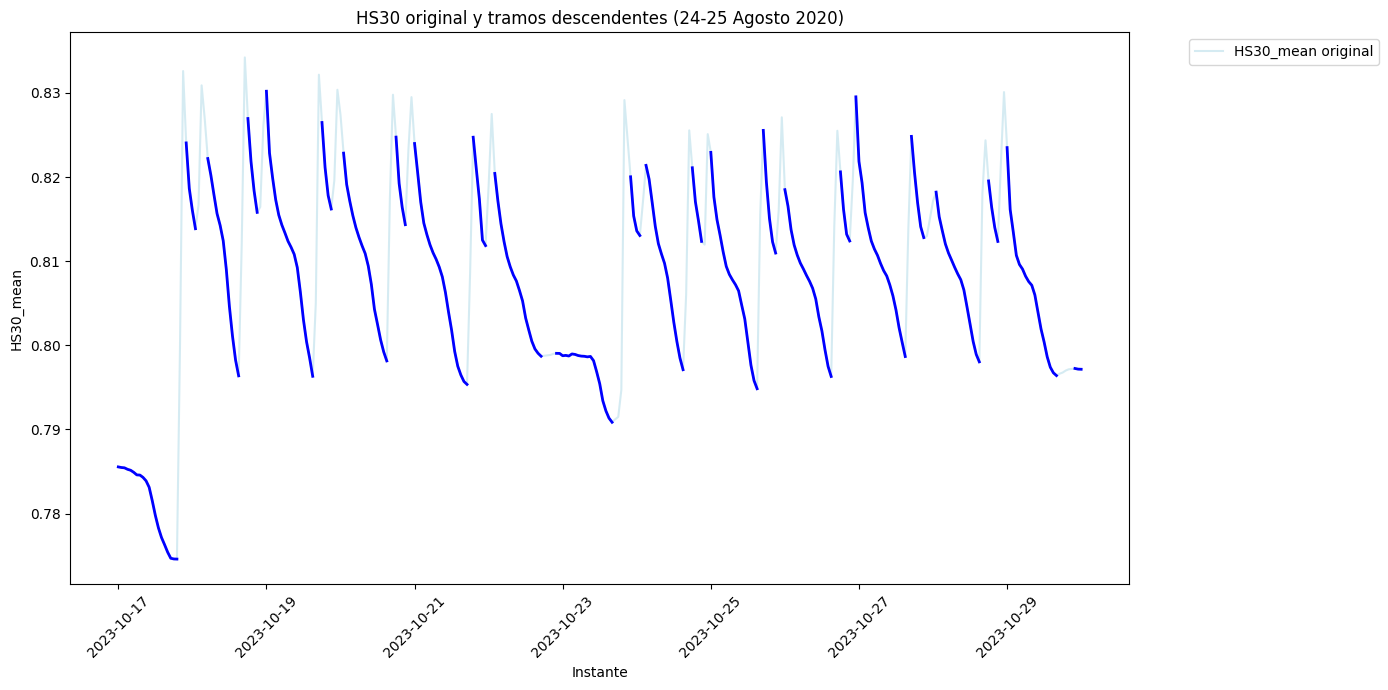

In [107]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Rango de fechas
start_date = "2023-10-17"
end_date = "2023-10-30"

mask_df = (df["instante"] >= start_date) & (df["instante"] <= end_date)
mask_desc = (df_desc3["instante"] >= start_date) & (df_desc3["instante"] <= end_date)

df_plot = df.loc[mask_df].sort_values("instante").set_index("instante")
df_desc_plot = df_desc3.loc[mask_desc].sort_values("instante").set_index("instante")

# Reindexar para asegurar huecos horarios
full_range = pd.date_range(start=start_date, end=end_date, freq="h")
df_plot = df_plot.reindex(full_range)
df_desc_plot = df_desc_plot.reindex(full_range)

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(14,7))

# HS30 original
ax.plot(df_plot.index, df_plot['HS30_mean'], label="HS30_mean original",
        alpha=0.5, color="lightblue")

# HS30 descendente por tramo
if "tramo_id" in df_desc_plot.columns:
    for tramo_id in df_desc_plot['tramo_id'].dropna().unique():
        tramo = df_desc_plot[df_desc_plot['tramo_id'] == tramo_id]
        ax.plot(tramo.index, tramo['HS30_mean'], color="blue", linewidth=2)

ax.set_xlabel("Instante")
ax.set_ylabel("HS30_mean")

"""
# Grid horario
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%H:%M'))
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
"""

# Leyenda
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("HS30 original y tramos descendentes (24-25 Agosto 2020)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## HS40

In [79]:
df_desc4 = (
    df.groupby("year", group_keys=False)
      .apply(detectar_tramos, columna="HS40_mean")
)

## HS50

In [80]:
df_desc5 = (
    df.groupby("year", group_keys=False)
      .apply(detectar_tramos, columna="HS50_mean")
)

## HS60

In [81]:
df_desc6 = (
    df.groupby("year", group_keys=False)
      .apply(detectar_tramos, columna="HS60_mean")
)

## Save

In [ ]:
import os

output_dir = "tramosDrenajeCorregido"
os.makedirs(output_dir, exist_ok=True)

dfs = [df_desc1, df_desc2, df_desc3, df_desc4, df_desc5, df_desc6]
hs_names = ["HS10", "HS20", "HS30", "HS40", "HS50", "HS60"]

for df_desc, hs_name in zip(dfs, hs_names):
    file_path = os.path.join(output_dir, f"{hs_name}_tramos.csv")
    df_desc.to_csv(file_path, index=False)
    print(f"Guardado {file_path}")

Guardado tramosDrenajeCorregido\HS10_tramos.csv
Guardado tramosDrenajeCorregido\HS20_tramos.csv
Guardado tramosDrenajeCorregido\HS30_tramos.csv
Guardado tramosDrenajeCorregido\HS40_tramos.csv
Guardado tramosDrenajeCorregido\HS50_tramos.csv
Guardado tramosDrenajeCorregido\HS60_tramos.csv


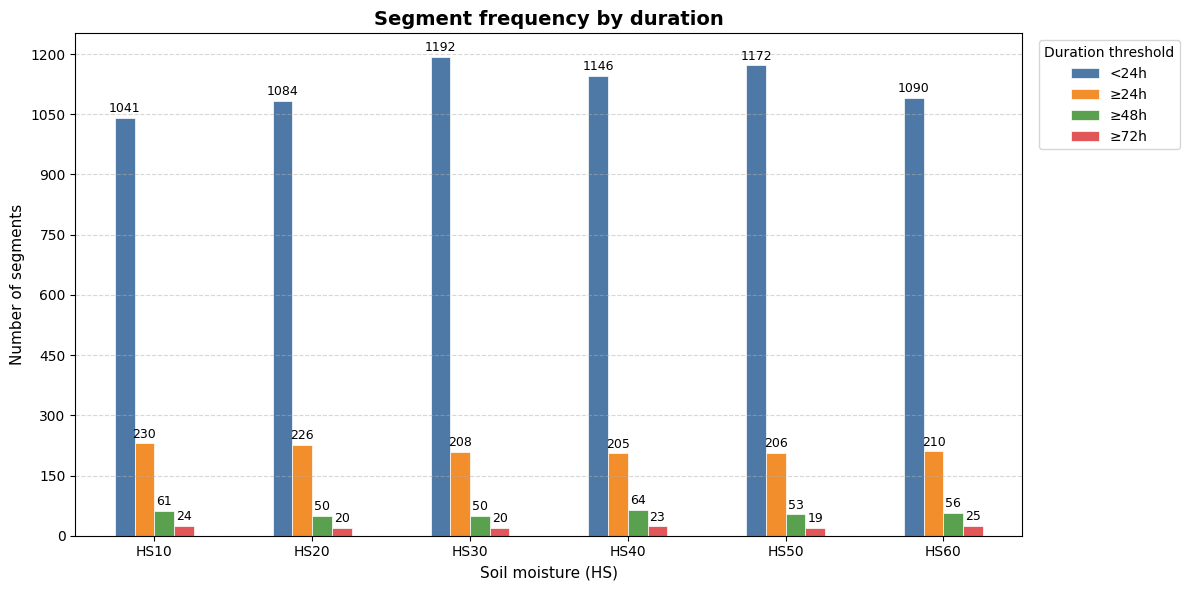

Saved: barplot_tramos_acumulados_HS.png

Cumulative summary by HS:
                    <24h  ≥24h  ≥48h  ≥72h
Soil Moisture (HS)                        
HS10                1041   230    61    24
HS20                1084   226    50    20
HS30                1192   208    50    20
HS40                1146   205    64    23
HS50                1172   206    53    19
HS60                1090   210    56    25


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
import glob

files = glob.glob("tramosDrenajeCorregido/*.csv")

dfs = []
for f in files:
    df = pd.read_csv(f)
    hs = os.path.basename(f).replace("_tramos.csv", "")
    df["HS"] = hs
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

segments = data.drop_duplicates(subset=["HS", "tramo_id"])[["HS", "tramo_id", "duracion_tramo"]].copy()

summary = pd.DataFrame(index=segments["HS"].unique())
summary.index.name = "Soil Moisture (HS)"
summary = summary.sort_index()

summary["<24h"]  = segments[segments["duracion_tramo"] < 24].groupby("HS").size()
summary["≥24h"]  = segments[segments["duracion_tramo"] >= 24].groupby("HS").size()
summary["≥48h"]  = segments[segments["duracion_tramo"] >= 48].groupby("HS").size()
summary["≥72h"]  = segments[segments["duracion_tramo"] >= 72].groupby("HS").size()

summary = summary.fillna(0).astype(int)
summary = summary.sort_index()

fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759"]
summary.plot(kind="bar", ax=ax, color=colors, edgecolor="white", linewidth=0.5)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: str(int(x)) if x > 0 else "",
        padding=2,
        fontsize=9
    )

ax.set_title(
    "Segment frequency by duration",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Soil moisture (HS)", fontsize=11)
ax.set_ylabel("Number of segments", fontsize=11)

ax.set_xticklabels(summary.index, rotation=0, fontsize=10)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

ax.legend(
    title="Duration threshold",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=10
)

ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("images/tramoD.png", dpi=150)
plt.show()

print("Saved: barplot_tramos_acumulados_HS.png")

print("\nCumulative summary by HS:")
print(summary.to_string())

Si queremos todas las HS desc concatenar csv con instante comun

# DF Riego

In [93]:
df = pd.read_csv("LC_horario.csv")
df = df.iloc[:, 1:]
df["instante"] = pd.to_datetime(df["instante"])
df = df.sort_values("instante").copy()
df["year"] = df["instante"].dt.year
df["month"] = df["instante"].dt.month
df = df[df["month"].between(3, 11)].copy()
df.shape

(26400, 48)

In [ ]:
def detectar_tramos_ascendente_riego_prev(grupo, columna_hs="HS10_mean",
                                           columna_riego="litros_incremento_sum",
                                           columna_precip="precipitacion"):
    grupo = grupo.sort_values("instante").copy()
    grupo = grupo[grupo[columna_hs].notna()].copy()
    
    tramo_id = 0
    tramo_list = []
    
    prev_hs = None
    
    # Riego en hora actual o anterior
    riego_reciente = (grupo[columna_riego] > 0) | (grupo[columna_riego].shift(1, fill_value=0) > 0)
    
    for idx, row in grupo.iterrows():
        val_hs = row[columna_hs]
        val_precip = row[columna_precip]
        val_riego_reciente = riego_reciente.loc[idx]
        
        if prev_hs is None:
            tramo_list.append(None)
        else:
            # HS sube, precipitación = 0, y riego reciente
            if val_hs > prev_hs and val_precip == 0 and val_riego_reciente:
                if tramo_list[-1] is None:
                    tramo_id += 1
                    tramo_list[-1] = tramo_id 
                tramo_list.append(tramo_id)
            else:
                tramo_list.append(None)
        prev_hs = val_hs
    
    grupo["tramo_id"] = tramo_list
    grupo_tramos = grupo.dropna(subset=["tramo_id"]).copy()
    grupo_tramos["tramo_id"] = grupo_tramos["tramo_id"].astype(int)
    
    grupo_tramos["duracion_tramo"] = grupo_tramos.groupby("tramo_id")["instante"].transform("size")
    
    grupo_tramos["duracion_horas"] = grupo_tramos.groupby("tramo_id")["instante"] \
        .transform(lambda x: (x.max() - x.min()).total_seconds()/3600 + 1)
    
    return grupo_tramos

## HS10

In [125]:
df_asc1 = df.groupby("year", group_keys=False).apply(
    detectar_tramos_ascendente_riego_prev, 
    columna_hs="HS10_mean")

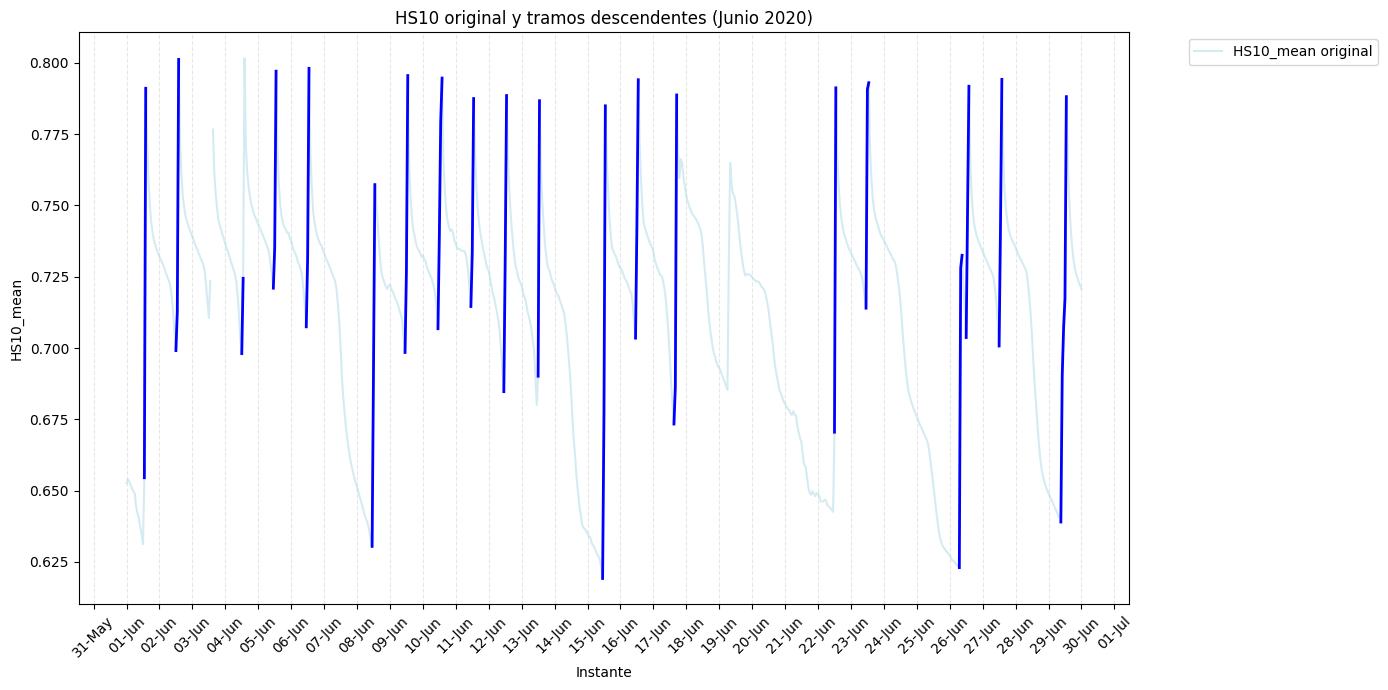

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

start_date = "2020-06-01"
end_date = "2020-06-30"

mask_df = (df["instante"] >= start_date) & (df["instante"] <= end_date)
mask_desc = (df_asc1["instante"] >= start_date) & (df_asc1["instante"] <= end_date)

df_plot = df.loc[mask_df].sort_values("instante").set_index("instante")
df_desc_plot = df_asc1.loc[mask_desc].sort_values("instante").set_index("instante")

full_range = pd.date_range(start=start_date, end=end_date, freq="h")
df_plot = df_plot.reindex(full_range)
df_desc_plot = df_desc_plot.reindex(full_range)

fig, ax = plt.subplots(figsize=(14,7))

# HS30 original
ax.plot(df_plot.index, df_plot['HS10_mean'], label="HS10_mean original",
        alpha=0.5, color="lightblue")

# HS30 descendente por tramo
if "tramo_id" in df_desc_plot.columns:
    for tramo_id in df_desc_plot['tramo_id'].dropna().unique():
        tramo = df_desc_plot[df_desc_plot['tramo_id'] == tramo_id]
        ax.plot(tramo.index, tramo['HS10_mean'], color="blue", linewidth=2)

ax.set_xlabel("Instante")
ax.set_ylabel("HS10_mean")

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.xaxis.set_major_locator(mdates.DayLocator())  # un tick por día
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax.grid(True, axis='x', linestyle='--', alpha=0.3)

plt.title("HS10 original y tramos descendentes (Junio 2020)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## HS20

In [133]:
df_asc2 = df.groupby("year", group_keys=False).apply(
    detectar_tramos_ascendente_riego_prev, 
    columna_hs="HS20_mean")

## HS30

In [134]:
df_asc3 = df.groupby("year", group_keys=False).apply(
    detectar_tramos_ascendente_riego_prev, 
    columna_hs="HS30_mean")

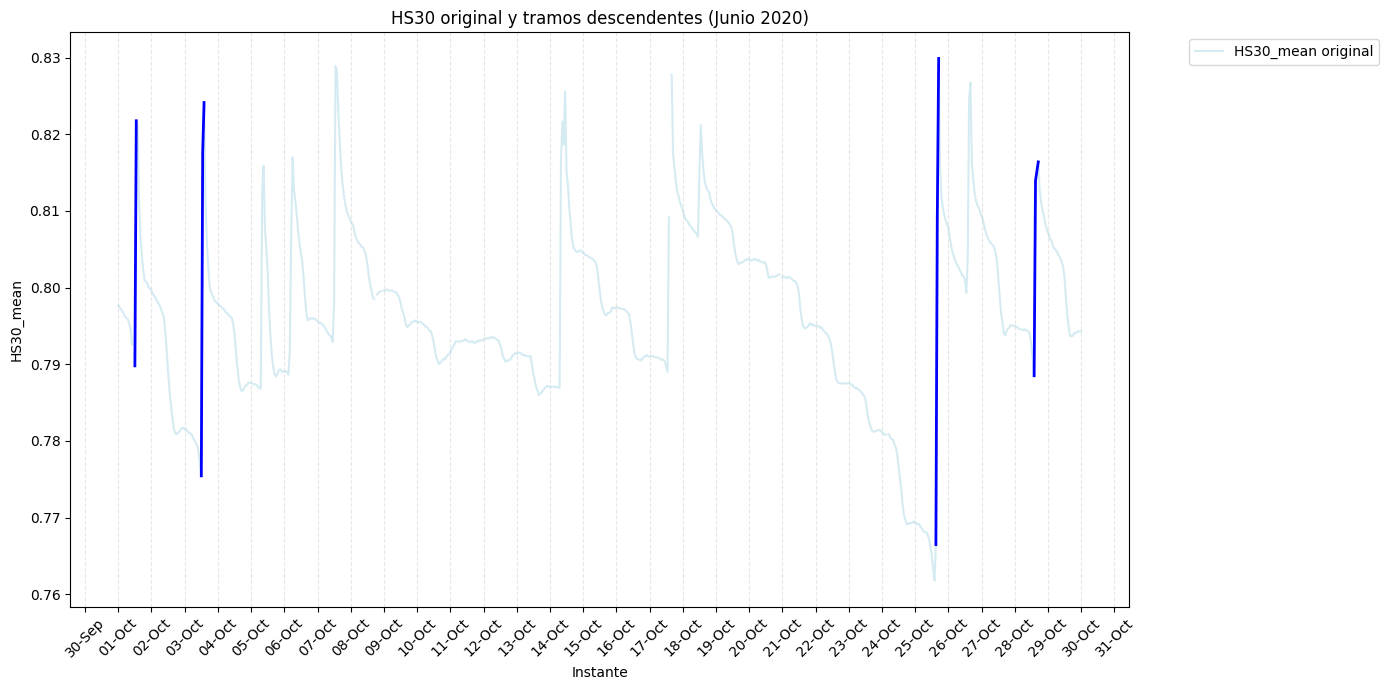

In [139]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# --- Rango de fechas ---
start_date = "2022-10-01"
end_date = "2022-10-30"

mask_df = (df["instante"] >= start_date) & (df["instante"] <= end_date)
mask_desc = (df_asc3["instante"] >= start_date) & (df_asc3["instante"] <= end_date)

df_plot = df.loc[mask_df].sort_values("instante").set_index("instante")
df_desc_plot = df_asc3.loc[mask_desc].sort_values("instante").set_index("instante")

# Reindexar para asegurar huecos horarios
full_range = pd.date_range(start=start_date, end=end_date, freq="h")
df_plot = df_plot.reindex(full_range)
df_desc_plot = df_desc_plot.reindex(full_range)

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(14,7))

# HS30 original
ax.plot(df_plot.index, df_plot['HS30_mean'], label="HS30_mean original",
        alpha=0.5, color="lightblue")

# HS30 descendente por tramo
if "tramo_id" in df_desc_plot.columns:
    for tramo_id in df_desc_plot['tramo_id'].dropna().unique():
        tramo = df_desc_plot[df_desc_plot['tramo_id'] == tramo_id]
        ax.plot(tramo.index, tramo['HS30_mean'], color="blue", linewidth=2)

ax.set_xlabel("Instante")
ax.set_ylabel("HS30_mean")

# --- Leyenda ---
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Opcional: grid por hora si quieres
ax.xaxis.set_major_locator(mdates.DayLocator())  # un tick por día
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax.grid(True, axis='x', linestyle='--', alpha=0.3)

plt.title("HS30 original y tramos descendentes (Junio 2020)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## HS40

In [147]:
df_asc4 = df.groupby("year", group_keys=False).apply(
    detectar_tramos_ascendente_riego_prev, 
    columna_hs="HS40_mean")

## HS50

In [148]:
df_asc5 = df.groupby("year", group_keys=False).apply(
    detectar_tramos_ascendente_riego_prev, 
    columna_hs="HS50_mean")

## HS60

In [149]:
df_asc6 = df.groupby("year", group_keys=False).apply(
    detectar_tramos_ascendente_riego_prev, 
    columna_hs="HS60_mean")

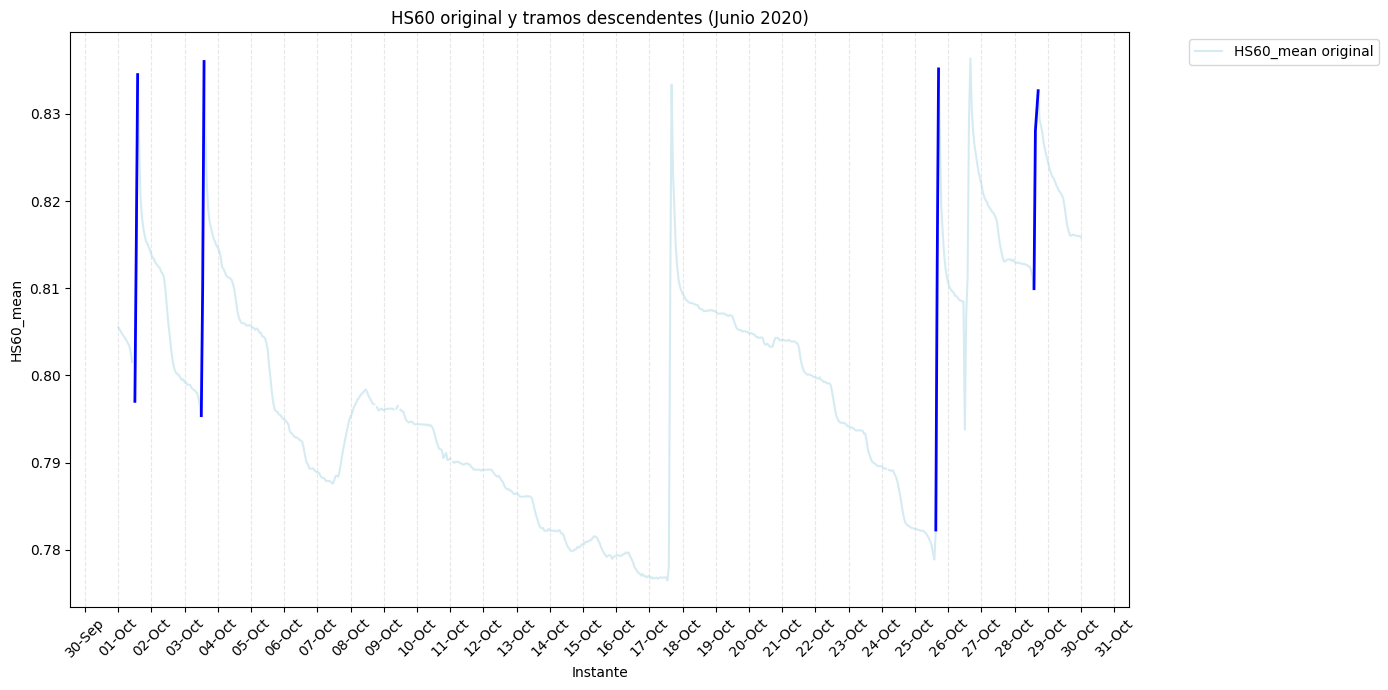

In [150]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# --- Rango de fechas ---
start_date = "2022-10-01"
end_date = "2022-10-30"

mask_df = (df["instante"] >= start_date) & (df["instante"] <= end_date)
mask_desc = (df_asc6["instante"] >= start_date) & (df_asc6["instante"] <= end_date)

df_plot = df.loc[mask_df].sort_values("instante").set_index("instante")
df_desc_plot = df_asc6.loc[mask_desc].sort_values("instante").set_index("instante")

# Reindexar para asegurar huecos horarios
full_range = pd.date_range(start=start_date, end=end_date, freq="h")
df_plot = df_plot.reindex(full_range)
df_desc_plot = df_desc_plot.reindex(full_range)

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(14,7))

# HS30 original
ax.plot(df_plot.index, df_plot['HS60_mean'], label="HS60_mean original",
        alpha=0.5, color="lightblue")

# HS30 descendente por tramo
if "tramo_id" in df_desc_plot.columns:
    for tramo_id in df_desc_plot['tramo_id'].dropna().unique():
        tramo = df_desc_plot[df_desc_plot['tramo_id'] == tramo_id]
        ax.plot(tramo.index, tramo['HS60_mean'], color="blue", linewidth=2)

ax.set_xlabel("Instante")
ax.set_ylabel("HS60_mean")

# --- Leyenda ---
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Opcional: grid por hora si quieres
ax.xaxis.set_major_locator(mdates.DayLocator())  # un tick por día
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax.grid(True, axis='x', linestyle='--', alpha=0.3)

plt.title("HS60 original y tramos descendentes (Junio 2020)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Save

In [155]:
import os

output_dir = "tramosRiego"
os.makedirs(output_dir, exist_ok=True)

dfs = [df_asc1, df_asc2, df_asc3, df_asc4, df_asc5, df_asc6]
hs_names = ["HS10", "HS20", "HS30", "HS40", "HS50", "HS60"]

for df_desc, hs_name in zip(dfs, hs_names):
    file_path = os.path.join(output_dir, f"{hs_name}_tramos.csv")
    df_desc.to_csv(file_path, index=False)
    print(f"Guardado {file_path}")

Guardado tramosRiego\HS10_tramos.csv
Guardado tramosRiego\HS20_tramos.csv
Guardado tramosRiego\HS30_tramos.csv
Guardado tramosRiego\HS40_tramos.csv
Guardado tramosRiego\HS50_tramos.csv
Guardado tramosRiego\HS60_tramos.csv


Longitud de tramos seleccionados y frec

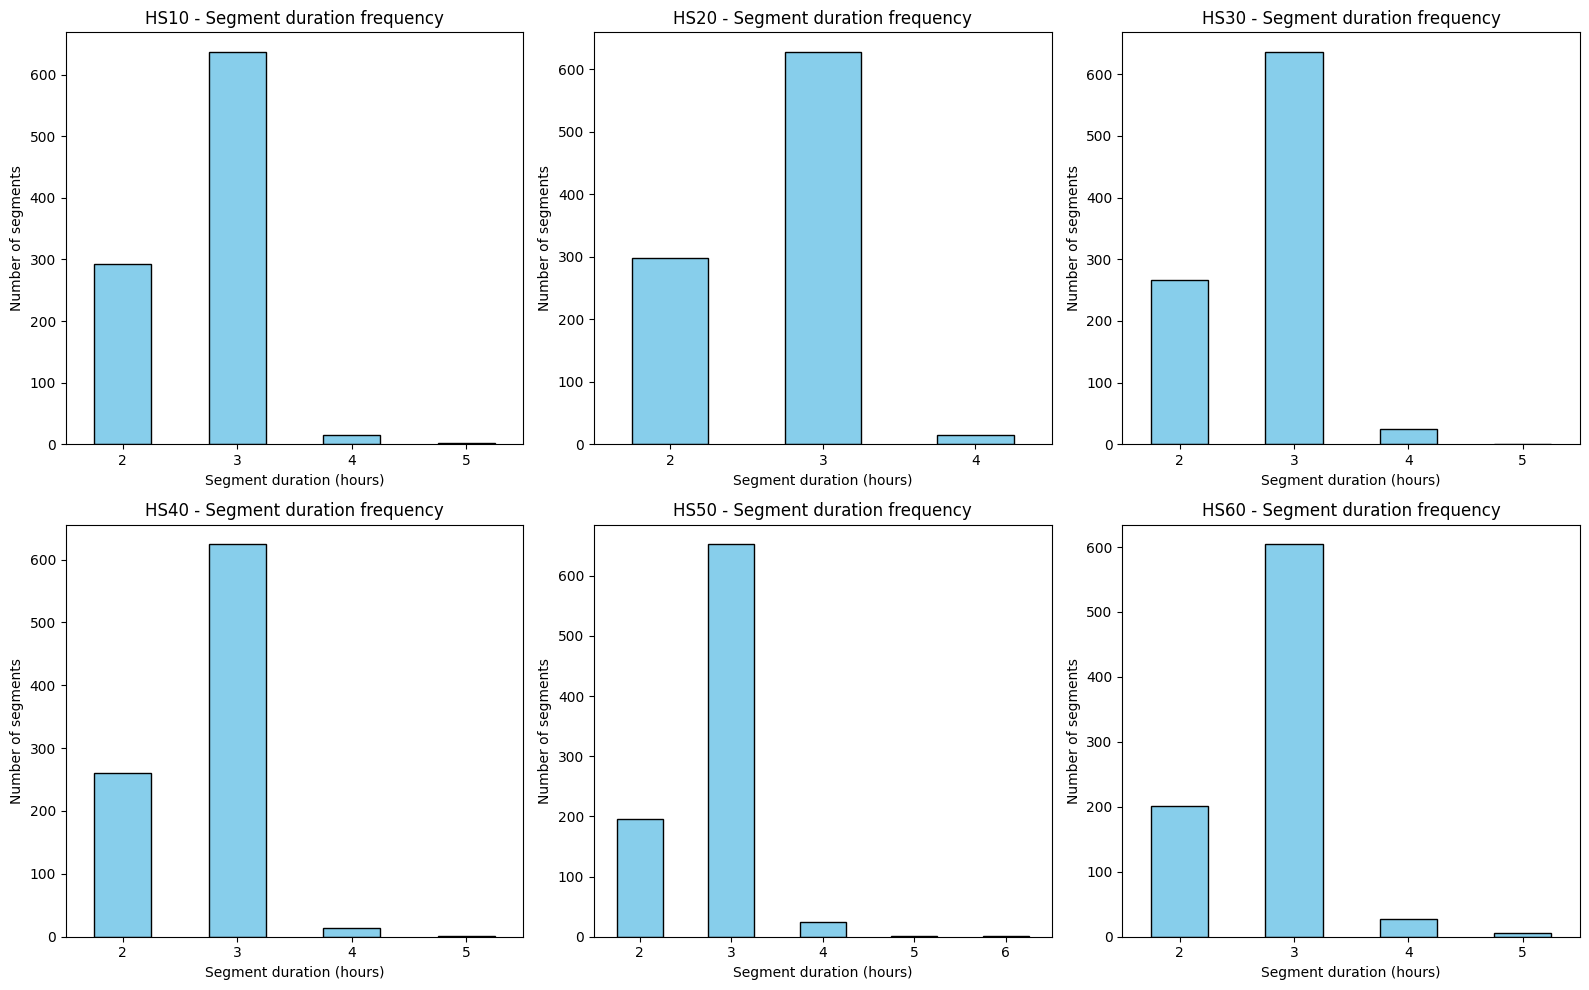

Saved figure: images\tramosR.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

input_dir = "tramosRiego"
output_dir = "images"
os.makedirs(output_dir, exist_ok=True)

hs_names = ["HS10", "HS20", "HS30", "HS40", "HS50", "HS60"]

plt.figure(figsize=(16, 10))

for i, hs_name in enumerate(hs_names, 1):
    file_path = os.path.join(input_dir, f"{hs_name}_tramos.csv")
    if not os.path.exists(file_path):
        continue

    df = pd.read_csv(file_path, parse_dates=["instante"])

    segments_duration = df[["tramo_id", "duracion_tramo"]].drop_duplicates()
    frequency = segments_duration.groupby("duracion_tramo")["tramo_id"].nunique()

    plt.subplot(2, 3, i)
    frequency.sort_index().plot(
        kind="bar",
        color="skyblue",
        edgecolor="black"
    )

    plt.title(f"{hs_name} - Segment duration frequency")
    plt.xlabel("Segment duration (hours)")
    plt.ylabel("Number of segments")
    plt.xticks(rotation=0)

plt.tight_layout()

output_path = os.path.join(output_dir, "tramosR.png")
plt.savefig(output_path, dpi=150)
plt.show()

print(f"Saved figure: {output_path}")

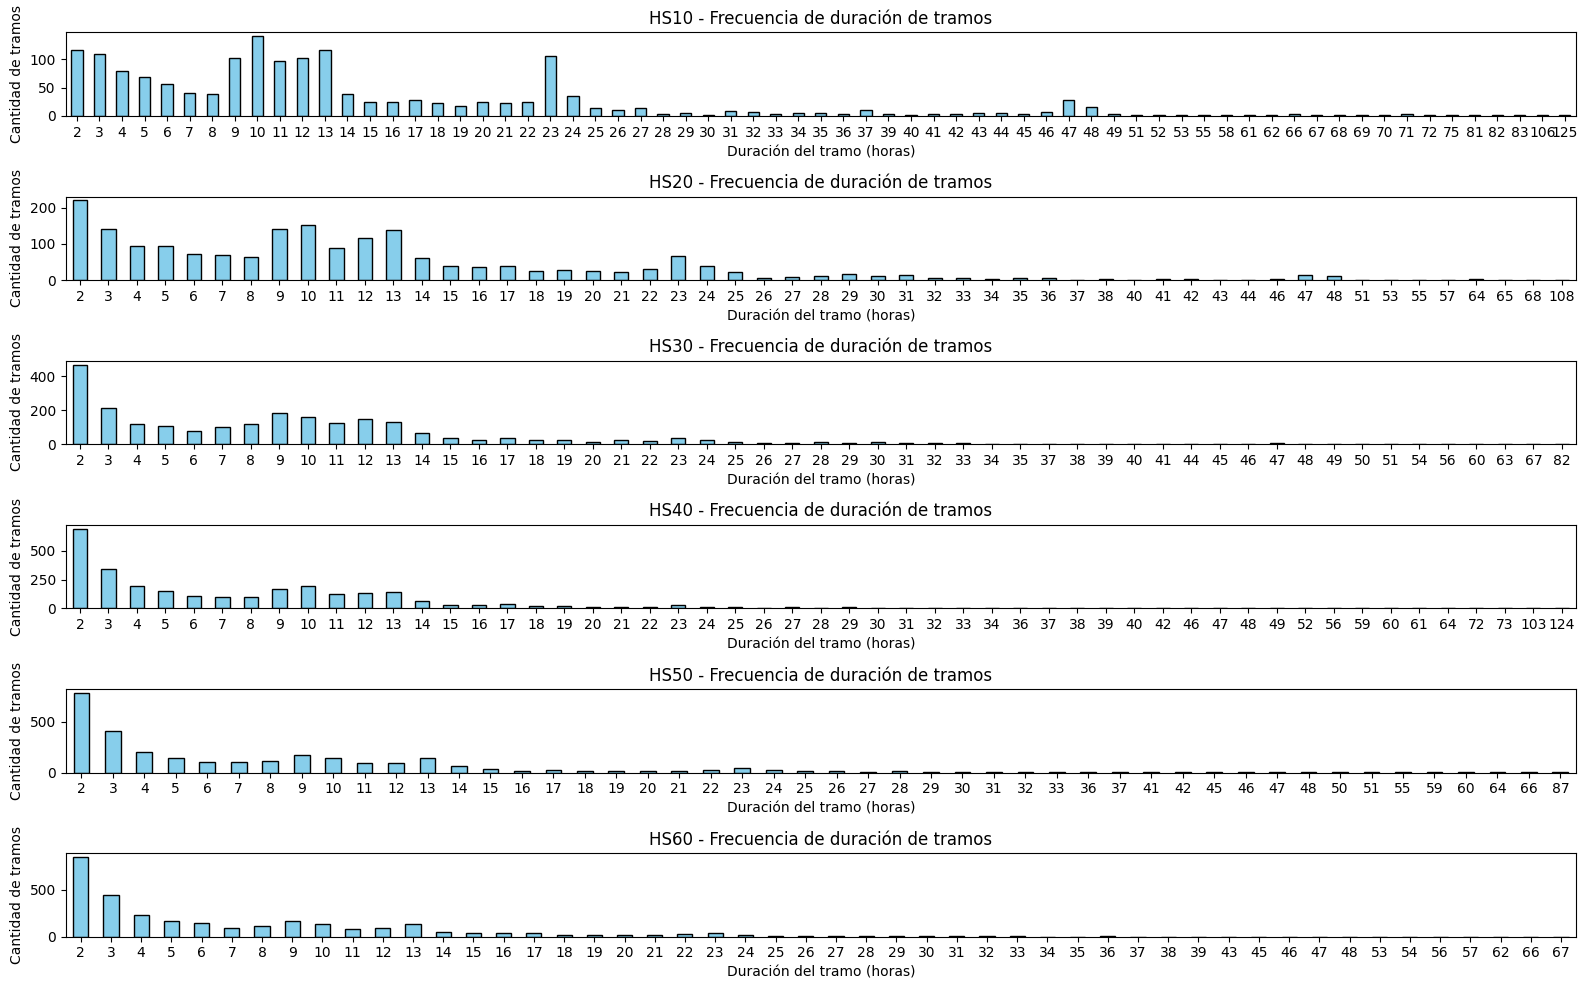

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

input_dir = "tramosDrenaje"
hs_names = ["HS10", "HS20", "HS30", "HS40", "HS50", "HS60"]

plt.figure(figsize=(16,10))

for i, hs_name in enumerate(hs_names, 1):
    file_path = os.path.join(input_dir, f"{hs_name}_tramos.csv")
    if not os.path.exists(file_path):
        continue
    
    df = pd.read_csv(file_path, parse_dates=["instante"])
    
    duraciones_tramos = df[["tramo_id", "duracion_tramo"]].drop_duplicates()
    frecuencia = duraciones_tramos.groupby("duracion_tramo")["tramo_id"].nunique()
    
    plt.subplot(6, 1, i)
    frecuencia.sort_index().plot(
        kind="bar", color="skyblue", edgecolor="black"
    )
    plt.title(f"{hs_name} - Frecuencia de duración de tramos")
    plt.xlabel("Duración del tramo (horas)")
    plt.ylabel("Cantidad de tramos")
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

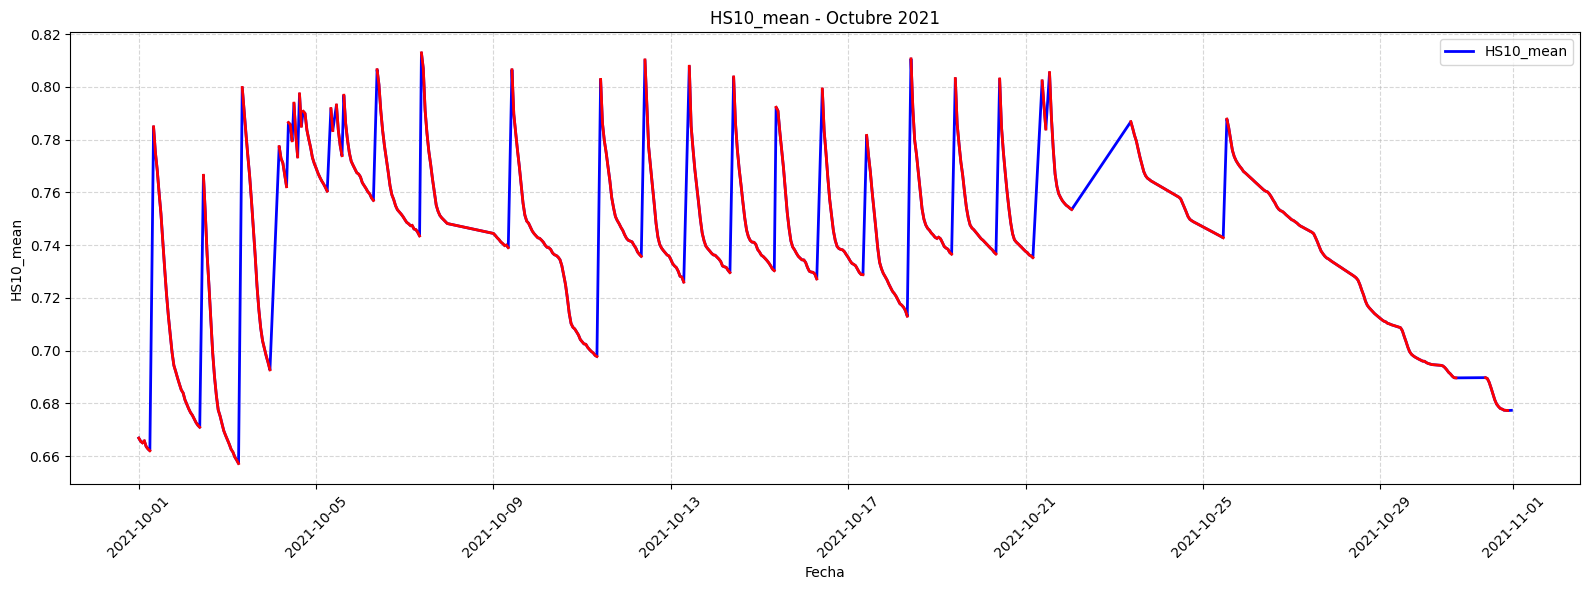

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

input_dir = "tramosDrenaje"
hs_name = "HS10"

file_path = os.path.join(input_dir, f"{hs_name}_tramos.csv")
if not os.path.exists(file_path):
    raise FileNotFoundError(f"No se encuentra el archivo {file_path}")

df = pd.read_csv(file_path, parse_dates=["instante"])

df_oct2021 = df[(df["instante"].dt.year == 2021) & (df["instante"].dt.month == 10)]

if df_oct2021.empty:
    print("No hay datos para HS10 en octubre 2021")
else:
    plt.figure(figsize=(16,6))
    plt.plot(df_oct2021["instante"], df_oct2021["HS10_mean"], color="blue", linewidth=2, label="HS10_mean")
    
    if "tramo_id" in df_oct2021.columns:
        for tramo_id in df_oct2021["tramo_id"].dropna().unique():
            tramo = df_oct2021[df_oct2021["tramo_id"] == tramo_id]
            plt.plot(tramo["instante"], tramo["HS10_mean"], color="red", linewidth=2)
    
    plt.title("HS10_mean - Octubre 2021")
    plt.xlabel("Fecha")
    plt.ylabel("HS10_mean")
    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

Corregir id tramo

In [ ]:
import os
import pandas as pd

input_dir = "tramosDrenajeCorregido"  
hs_names = ["HS10", "HS20", "HS30", "HS40", "HS50", "HS60"]

for hs_name in hs_names:
    file_path = os.path.join(input_dir, f"{hs_name}_tramos.csv")
    if not os.path.exists(file_path):
        continue

    df = pd.read_csv(file_path, parse_dates=["instante"])
    
    df["year"] = df["instante"].dt.year
    
    df["tramo_id"] = df["year"].astype(str) + "-" + df["tramo_id"].astype(str)
    
    df.to_csv(file_path, index=False)
    print(f"{hs_name} actualizado con tramo_id único por año en {file_path}")

HS10 actualizado con tramo_id único por año en tramosDrenajeCorregido\HS10_tramos.csv
HS20 actualizado con tramo_id único por año en tramosDrenajeCorregido\HS20_tramos.csv
HS30 actualizado con tramo_id único por año en tramosDrenajeCorregido\HS30_tramos.csv
HS40 actualizado con tramo_id único por año en tramosDrenajeCorregido\HS40_tramos.csv
HS50 actualizado con tramo_id único por año en tramosDrenajeCorregido\HS50_tramos.csv
HS60 actualizado con tramo_id único por año en tramosDrenajeCorregido\HS60_tramos.csv


In [ ]:
import pandas as pd
import os
import glob

archivos = glob.glob("tramosDrenajeCorregido/*.csv")

cols_mean = [f"HS{i}0_mean" for i in range(1, 7)] + ["TS30_mean", "TA_mean"]
cols_resto = [
    "instante",
    "litros_incremento_sum",
    "tmedia", "hmedia", "radiacion", "viento", "direccion", "precipitacion",
    "tramo_id", "duracion_tramo"
]

rename_map = {col: col.replace("_mean", "") for col in cols_mean}

for f in archivos:
    df = pd.read_csv(f)
    cols_disponibles = [c for c in cols_resto + cols_mean if c in df.columns]
    df = df[cols_disponibles]

    df = df.rename(columns=rename_map)

    df.to_csv(f, index=False)
    print(f"Actualizado: {os.path.basename(f)} — columnas: {list(df.columns)}")

Actualizado: HS10_tramos.csv — columnas: ['instante', 'litros_incremento_sum', 'tmedia', 'hmedia', 'radiacion', 'viento', 'direccion', 'precipitacion', 'tramo_id', 'duracion_tramo', 'HS10', 'HS20', 'HS30', 'HS40', 'HS50', 'HS60', 'TS30', 'TA']
Actualizado: HS20_tramos.csv — columnas: ['instante', 'litros_incremento_sum', 'tmedia', 'hmedia', 'radiacion', 'viento', 'direccion', 'precipitacion', 'tramo_id', 'duracion_tramo', 'HS10', 'HS20', 'HS30', 'HS40', 'HS50', 'HS60', 'TS30', 'TA']
Actualizado: HS30_tramos.csv — columnas: ['instante', 'litros_incremento_sum', 'tmedia', 'hmedia', 'radiacion', 'viento', 'direccion', 'precipitacion', 'tramo_id', 'duracion_tramo', 'HS10', 'HS20', 'HS30', 'HS40', 'HS50', 'HS60', 'TS30', 'TA']
Actualizado: HS40_tramos.csv — columnas: ['instante', 'litros_incremento_sum', 'tmedia', 'hmedia', 'radiacion', 'viento', 'direccion', 'precipitacion', 'tramo_id', 'duracion_tramo', 'HS10', 'HS20', 'HS30', 'HS40', 'HS50', 'HS60', 'TS30', 'TA']
Actualizado: HS50_tramos